In [2]:
import seaborn as sns
import pandas as pd

# Cargar el conjunto de datos MPG
mpg_df = sns.load_dataset('mpg')

# Mostrar las primeras 5 filas del DataFrame
mpg_df.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


## Conjunto de Datos MPG

El conjunto de datos "MPG" (millas por galón) es un conjunto de datos clásico utilizado en estadística y aprendizaje automático. Contiene información sobre el consumo de combustible de varios automóviles.

**Características del conjunto de datos:**

*   **mpg:** Millas por galón (variable objetivo).
*   **cylinders:** Número de cilindros del motor.
*   **displacement:** Cilindrada del motor.
*   **horsepower:** Caballos de fuerza.
*   **weight:** Peso del automóvil.
*   **acceleration:** Aceleración.
*   **model year:** Año del modelo.
*   **origin:** Origen del automóvil (1: Americano, 2: Europeo, 3: Japonés).
*   **name:** Nombre del automóvil.

Este conjunto de datos es ideal para practicar la regresión lineal, ya que podemos intentar predecir el `mpg` de un automóvil basándonos en sus otras características.


## Análisis de los Datos

### Tipos de Datos y Valores Nulos

Al ejecutar `mpg_df.info()`, observamos lo siguiente:
*   El DataFrame tiene 398 entradas.
*   La columna `horsepower` tiene 392 valores no nulos, lo que indica que hay 6 valores faltantes.
*   La mayoría de las columnas son numéricas (`float64` o `int64`), lo cual es adecuado para la regresión.
*   Las columnas `origin` y `name` son de tipo `object`. `origin` podría ser tratada como una variable categórica.

### Estadísticas Descriptivas

El método `mpg_df.describe()` nos proporciona un resumen estadístico de las columnas numéricas:

*   **mpg:** El consumo medio de combustible es de aproximadamente 23.5 millas por galón, con una desviación estándar de 7.8. Los valores van desde 9 hasta 46.6.
*   **horsepower:** La potencia media es de unos 104 caballos de fuerza. Sin embargo, debemos tener en cuenta los valores faltantes antes de usar esta columna en un modelo. El rango va de 46 a 230.
*   **weight:** El peso promedio de los coches es de 2970 libras. Existe una correlación negativa esperada entre el peso y el mpg (a mayor peso, menor mpg).
*   **model year:** Los datos cubren coches desde el año 70 hasta el 82.

Este análisis inicial es crucial para los siguientes pasos de preprocesamiento de datos, como el manejo de valores faltantes y la posible codificación de variables categóricas.

In [3]:
# Obtener información sobre los tipos de datos y valores no nulos
print("Información del DataFrame:")
mpg_df.info()

print("\n" + "="*50 + "\n")

# Obtener estadísticas descriptivas
print("Estadísticas Descriptivas:")
mpg_df.describe()

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


Estadísticas Descriptivas:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [4]:
# 1. Eliminar filas con datos faltantes
mpg_df = mpg_df.dropna()

# 2. Almacenar y eliminar la columna 'name'
vehicle_names = mpg_df['name']
mpg_df = mpg_df.drop('name', axis=1)

# 3. Realizar codificación One-Hot en la columna 'origin'
origin_dummies = pd.get_dummies(mpg_df['origin'], prefix='origin')
mpg_df = pd.concat([mpg_df, origin_dummies], axis=1)
mpg_df = mpg_df.drop('origin', axis=1)

# Mostrar las primeras filas del DataFrame procesado
mpg_df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_europe,origin_japan,origin_usa
0,18.0,8,307.0,130.0,3504,12.0,70,False,False,True
1,15.0,8,350.0,165.0,3693,11.5,70,False,False,True
2,18.0,8,318.0,150.0,3436,11.0,70,False,False,True
3,16.0,8,304.0,150.0,3433,12.0,70,False,False,True
4,17.0,8,302.0,140.0,3449,10.5,70,False,False,True


## Preprocesamiento de Datos

Antes de entrenar un modelo de regresión, es fundamental limpiar y preparar los datos. Realizaremos los siguientes pasos:

1.  **Manejo de Valores Faltantes:** Eliminaremos las filas que contengan valores nulos. En nuestro caso, esto afecta a la columna `horsepower`.
2.  **Extracción y Eliminación de Nombres:** Guardaremos los nombres de los coches en una variable separada y luego eliminaremos la columna `name` del DataFrame, ya que no es una característica útil para la predicción en su forma actual.
3.  **Codificación One-Hot para 'origin':** La columna `origin` es categórica. La convertiremos en variables numéricas utilizando la técnica de codificación one-hot. Esto creará nuevas columnas para cada categoría de origen (EE. UU., Europa, Japón), con valores de 1 o 0.

In [7]:
# importar NumPy
import numpy as np


# Seleccionar solo columnas numéricas para el cálculo
numeric_cols = mpg_df.select_dtypes(include=np.number)

# Calcular la media y la desviación estándar para cada columna
mean = numeric_cols.mean()
std = numeric_cols.std()

# Aplicar la fórmula del Z-score: (X - media) / std
z_scores_df_manual = (numeric_cols - mean) / std

# Mostrar las primeras 5 filas de los Z-scores calculados manualmente
print("Z-Scores calculados manualmente:")
z_scores_df_manual.head()

Z-Scores calculados manualmente:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
0,-0.697747,1.482053,1.075915,0.663285,0.619748,-1.283618,-1.623241
1,-1.082115,1.482053,1.486832,1.572585,0.842258,-1.464852,-1.623241
2,-0.697747,1.482053,1.181033,1.182885,0.539692,-1.646086,-1.623241
3,-0.953992,1.482053,1.047246,1.182885,0.536160,-1.283618,-1.623241
4,-0.825870,1.482053,1.028134,0.923085,0.554997,-1.827320,-1.623241


## Estandarización con Z-Score

El **Z-score** (o puntuación estándar) es una medida estadística que describe la posición de un punto de datos en relación con la media de un grupo de puntos de datos. Se mide en términos de desviaciones estándar de la media.

**¿Para qué sirve?**

*   **Estandarización de Datos:** Permite comparar valores de diferentes distribuciones. Al convertir los datos a una escala común (media 0, desviación estándar 1), podemos trabajar con características que originalmente tenían diferentes unidades y rangos.
*   **Detección de Outliers:** Un Z-score alto (generalmente > 3 o < -3) puede indicar que un punto de datos es un outlier o un valor atípico.
*   **Preparación para Algoritmos:** Muchos algoritmos de aprendizaje automático, como la regresión lineal, PCA, y redes neuronales, funcionan mejor o convergen más rápido cuando las características de entrada están estandarizadas.

**Fórmula:**

`Z = (X - μ) / σ`

Donde:
- `X` es el punto de datos.
- `μ` es la media de la población.
- `σ` es la desviación estándar de la población.

In [8]:
# Definir el umbral para considerar un valor como atípico
threshold = 2

# Filtrar los vehículos con un Z-score de 'mpg' mayor que el umbral (alto rendimiento)
high_mpg_outliers = z_scores_df_manual[z_scores_df_manual['mpg'] > threshold]

# Filtrar los vehículos con un Z-score de 'mpg' menor que el negativo del umbral (bajo rendimiento)
low_mpg_outliers = z_scores_df_manual[z_scores_df_manual['mpg'] < -threshold]

print("--- Vehículos con MPG Anormalmente Alto (Z-score > 2) ---")
# Iterar sobre los outliers de alto MPG para mostrar su ID y nombre
for idx in high_mpg_outliers.index:
    vehicle_name = vehicle_names.loc[idx]
    mpg_value = mpg_df.loc[idx, 'mpg']
    z_score_value = high_mpg_outliers.loc[idx, 'mpg']
    print(f"ID: {idx}, Marca: {vehicle_name:<30} | MPG: {mpg_value}, Z-score: {z_score_value:.2f}")

print("\n" + "="*60 + "\n")

print("--- Vehículos con MPG Anormalmente Bajo (Z-score < -2) ---")
# Iterar sobre los outliers de bajo MPG para mostrar su ID y nombre
for idx in low_mpg_outliers.index:
    vehicle_name = vehicle_names.loc[idx]
    mpg_value = mpg_df.loc[idx, 'mpg']
    z_score_value = low_mpg_outliers.loc[idx, 'mpg']
    print(f"ID: {idx}, Marca: {vehicle_name:<30} | MPG: {mpg_value}, Z-score: {z_score_value:.2f}")

--- Vehículos con MPG Anormalmente Alto (Z-score > 2) ---
ID: 244, Marca: volkswagen rabbit custom diesel | MPG: 43.1, Z-score: 2.52
ID: 247, Marca: datsun b210 gx                 | MPG: 39.4, Z-score: 2.04
ID: 309, Marca: vw rabbit                      | MPG: 41.5, Z-score: 2.31
ID: 322, Marca: mazda glc                      | MPG: 46.6, Z-score: 2.97
ID: 324, Marca: datsun 210                     | MPG: 40.8, Z-score: 2.22
ID: 325, Marca: vw rabbit c (diesel)           | MPG: 44.3, Z-score: 2.67
ID: 326, Marca: vw dasher (diesel)             | MPG: 43.4, Z-score: 2.56
ID: 329, Marca: honda civic 1500 gl            | MPG: 44.6, Z-score: 2.71
ID: 343, Marca: toyota starlet                 | MPG: 39.1, Z-score: 2.01
ID: 394, Marca: vw pickup                      | MPG: 44.0, Z-score: 2.63


--- Vehículos con MPG Anormalmente Bajo (Z-score < -2) ---


## Análisis de Outliers con Z-Score

Una de las aplicaciones más útiles del Z-score es la detección de valores atípicos (outliers). Un Z-score nos indica cuántas desviaciones estándar se aleja un punto de datos de la media.

Podemos establecer un umbral para identificar estos outliers. Por ejemplo, un Z-score mayor que 2 o menor que -2 a menudo se considera inusual, ya que significa que el punto de datos está a más de dos desviaciones estándar de la media.

En el siguiente bloque de código, identificaremos los vehículos que tienen un `mpg` (millas por galón) significativamente alto o bajo utilizando este método. Filtraremos los datos para encontrar aquellos cuyo Z-score de `mpg` esté fuera del rango `[-2, 2]`.

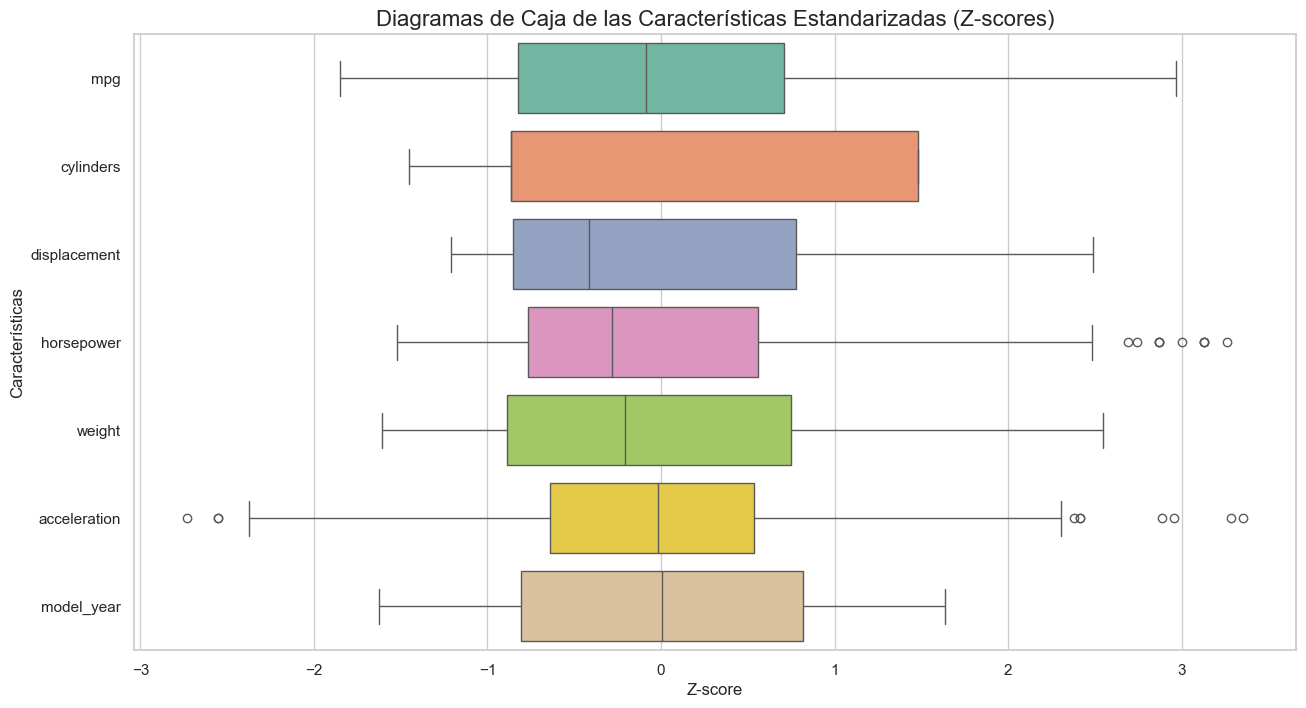

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo de la visualización
sns.set(style="whitegrid")

# Crear la figura para los diagramas de caja
plt.figure(figsize=(15, 8))

# Crear los diagramas de caja para cada columna numérica en el DataFrame de Z-scores
sns.boxplot(data=z_scores_df_manual, orient="h", palette="Set2")

# Añadir títulos y etiquetas
plt.title('Diagramas de Caja de las Características Estandarizadas (Z-scores)', fontsize=16)
plt.xlabel('Z-score', fontsize=12)
plt.ylabel('Características', fontsize=12)

# Mostrar el gráfico
plt.show()

## Visualización con Diagramas de Caja (Box Plots)

Los diagramas de caja son una forma estandarizada de mostrar la distribución de los datos basada en un resumen de cinco números: mínimo, primer cuartil (Q1), mediana (Q2), tercer cuartil (Q3) y máximo.

**¿Para qué sirven?**

*   **Identificar Outliers:** Los puntos que se encuentran fuera de los "bigotes" del diagrama de caja (generalmente 1.5 veces el rango intercuartílico por encima de Q3 o por debajo de Q1) se consideran valores atípicos.
*   **Comparar Distribuciones:** Permiten comparar rápidamente la dispersión y la tendencia central de diferentes variables.
*   **Evaluar la Simetría:** La posición de la mediana en la caja y la longitud de los bigotes nos dan una idea de si la distribución de los datos es simétrica o sesgada.

En el siguiente bloque, generaremos diagramas de caja para todas nuestras variables numéricas (ya estandarizadas con el Z-score) para visualizar sus distribuciones y detectar posibles outliers en cada una.

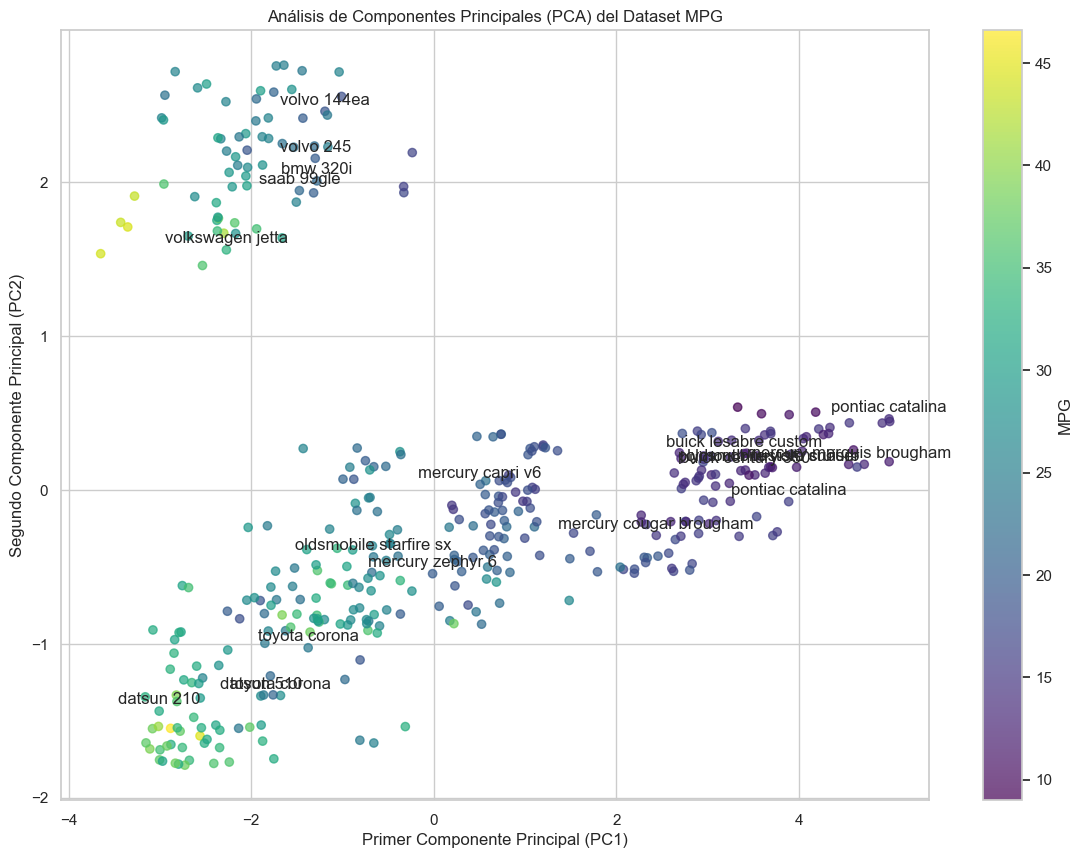

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Separar las características (X) de la variable objetivo (y)
X = mpg_df.drop('mpg', axis=1)
y = mpg_df['mpg']

# 1. Estandarizar los datos (usando el DataFrame sin Z-score previo)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Aplicar PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Crear un DataFrame con los componentes principales y el índice original
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'], index=X.index)

# 3. Visualizar los componentes principales
plt.figure(figsize=(14, 10))
scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=y, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='MPG')
plt.xlabel('Primer Componente Principal (PC1)')
plt.ylabel('Segundo Componente Principal (PC2)')
plt.title('Análisis de Componentes Principales (PCA) del Dataset MPG')
plt.grid(True)

# Añadir etiquetas a un subconjunto aleatorio de puntos
indices_to_annotate = np.random.choice(pca_df.index, size=20, replace=False)
for i in indices_to_annotate:
    plt.annotate(vehicle_names[i], 
                 (pca_df.loc[i, 'PC1'], pca_df.loc[i, 'PC2']),
                 textcoords="offset points",
                 xytext=(0,5),
                 ha='center')

plt.show()

## Visualización con Análisis de Componentes Principales (PCA)

El Análisis de Componentes Principales (PCA) es una técnica de reducción de dimensionalidad que nos permite proyectar un conjunto de datos de alta dimensión en un espacio de menor dimensión (generalmente 2 o 3 componentes) para su visualización.

**Pasos a seguir:**

1.  **Estandarización:** Antes de aplicar PCA, es crucial estandarizar las características para que todas tengan una media de 0 y una desviación estándar de 1. Esto evita que las variables con escalas más grandes dominen el análisis.
2.  **Cálculo de Componentes:** Se calculan los componentes principales, que son nuevas variables (combinaciones lineales de las originales) que capturan la máxima varianza posible de los datos.
3.  **Visualización:** Se crea un gráfico de dispersión utilizando los dos primeros componentes principales (PC1 y PC2). Cada punto en el gráfico representa un automóvil, y su posición está determinada por los valores de sus componentes principales. Anotaremos algunos de estos puntos con el nombre del vehículo para facilitar la interpretación.

Número de componentes para explicar al menos el 85% de la varianza: 4


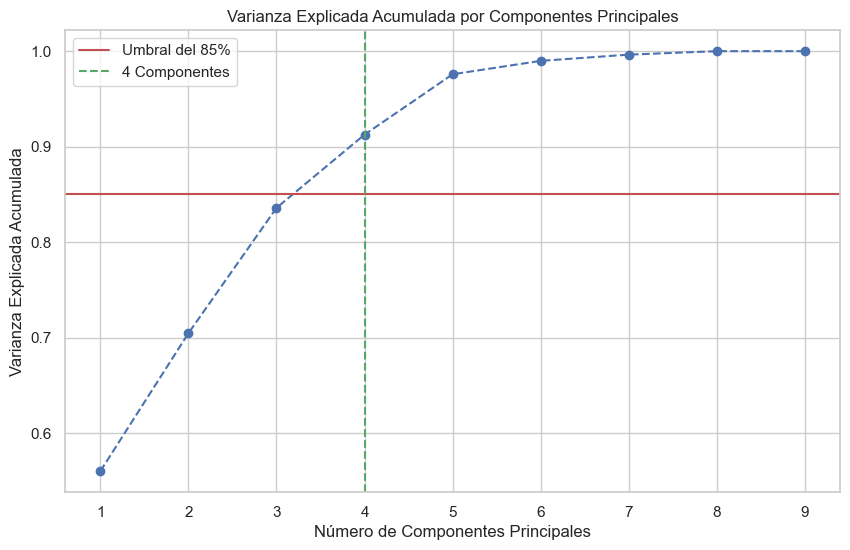

In [11]:
# Aplicar PCA sin reducir el número de componentes para analizar la varianza
pca_full = PCA()
pca_full.fit(X_scaled)

# Calcular la varianza acumulada
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Determinar el número de componentes para alcanzar el 85% de la varianza
n_components_85 = np.argmax(cumulative_variance >= 0.85) + 1

print(f"Número de componentes para explicar al menos el 85% de la varianza: {n_components_85}")

# Visualizar la varianza explicada acumulada
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.85, color='r', linestyle='-', label='Umbral del 85%')
plt.axvline(x=n_components_85, color='g', linestyle='--', label=f'{n_components_85} Componentes')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Varianza Explicada Acumulada por Componentes Principales')
plt.legend()
plt.grid(True)
plt.show()

## Selección de Componentes Principales mediante Varianza Acumulada

Una pregunta clave al usar PCA es: ¿cuántos componentes principales debemos conservar? No queremos reducir demasiado la dimensionalidad y perder información valiosa, pero tampoco queremos quedarnos con demasiados componentes, lo que anularía el propósito de la reducción.

Una técnica común es observar la **varianza explicada acumulada**. Cada componente principal captura una cierta cantidad de la varianza total de los datos. Al trazar la suma acumulada de esta varianza, podemos ver cuánta información se retiene a medida que agregamos más componentes.

Nuestro objetivo es seleccionar el número mínimo de componentes que expliquen un porcentaje significativo de la varianza total. En este caso, estableceremos un umbral del **85%**. Buscaremos el punto en el que la curva de varianza acumulada cruza esta línea, lo que nos indicará el número óptimo de componentes a retener para nuestro análisis.

In [12]:
# Aplicar PCA nuevamente, esta vez reteniendo solo los 5 componentes principales
pca_final = PCA(n_components=5)
X_pca_5 = pca_final.fit_transform(X_scaled)

# Crear un DataFrame final con los 5 componentes principales
X_pca_5_df = pd.DataFrame(data=X_pca_5, 
                          columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'], 
                          index=X.index)

# Mostrar las primeras filas del nuevo DataFrame
print("DataFrame con los 5 componentes principales seleccionados:")
X_pca_5_df.head()

DataFrame con los 5 componentes principales seleccionados:


,PC1,PC2,PC3,PC4,PC5
0,2.721899,0.366428,0.710922,-0.838203,-0.471541
1,3.412260,0.398098,1.023988,-0.562838,-0.387442
2,3.045843,0.371134,1.013285,-0.648163,-0.721605
3,2.887396,0.381552,0.841870,-0.765764,-0.484207
4,2.929269,0.358933,1.028666,-0.649985,-0.892256


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# 1. Dividir los datos en conjuntos de entrenamiento y prueba
# Usaremos un 80% para entrenamiento y un 20% para prueba
X_train, X_test, y_train, y_test = train_test_split(X_pca_5_df, y, test_size=0.2, random_state=42)

# 2. Crear y entrenar el modelo de regresión lineal
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 3. Realizar predicciones en el conjunto de prueba
y_pred = lr_model.predict(X_test)

# 4. Evaluar el modelo y mostrar las métricas
print('--- Reporte de Métricas de Evaluación ---')
print(f'Error Absoluto Medio (MAE): {metrics.mean_absolute_error(y_test, y_pred):.2f}')
print(f'Error Cuadrático Medio (MSE): {metrics.mean_squared_error(y_test, y_pred):.2f}')
print(f'Raíz del Error Cuadrático Medio (RMSE): {np.sqrt(metrics.mean_squared_error(y_test, y_pred)):.2f}')
print(f'Coeficiente de Determinación (R²): {metrics.r2_score(y_test, y_pred):.2f}')

--- Reporte de Métricas de Evaluación ---
Error Absoluto Medio (MAE): 2.62
Error Cuadrático Medio (MSE): 12.70
Raíz del Error Cuadrático Medio (RMSE): 3.56
Coeficiente de Determinación (R²): 0.75


## Entrenamiento y Evaluación del Modelo de Regresión Lineal

Con nuestros datos preprocesados y reducidos a 5 componentes principales, estamos listos para entrenar el modelo.

**Pasos a seguir:**

1.  **División de Datos (Train/Test Split):** Dividiremos nuestro conjunto de datos en dos partes:
    *   **Conjunto de Entrenamiento (Training Set):** Se utilizará para que el algoritmo de regresión lineal "aprenda" los patrones en los datos. Típicamente, es la mayor parte de los datos (por ejemplo, 80%).
    *   **Conjunto de Prueba (Test Set):** Se mantendrá separado y se usará para evaluar qué tan bien generaliza nuestro modelo a datos nuevos y no vistos.

2.  **Entrenamiento del Modelo:** Crearemos una instancia del modelo `LinearRegression` y lo ajustaremos (`fit`) utilizando el conjunto de entrenamiento.

3.  **Evaluación del Modelo:** Realizaremos predicciones sobre el conjunto de prueba y compararemos estas predicciones con los valores reales. Para cuantificar el rendimiento, utilizaremos las siguientes métricas:
    *   **Error Absoluto Medio (MAE):** El promedio de las diferencias absolutas entre los valores predichos y los reales. Es fácil de interpretar, ya que está en las mismas unidades que la variable objetivo.
    *   **Error Cuadrático Medio (MSE):** El promedio de las diferencias al cuadrado. Penaliza más los errores grandes.
    *   **Raíz del Error Cuadrático Medio (RMSE):** La raíz cuadrada del MSE. También está en las mismas unidades que la variable objetivo y es una de las métricas más populares.
    *   **Coeficiente de Determinación (R²):** Indica la proporción de la varianza en la variable dependiente que es predecible a partir de las variables independientes. Un valor cercano a 1 indica un buen ajuste del modelo.

## Justificación de la Selección de 5 Componentes

Como se observa en la gráfica de varianza acumulada, la curva muestra un "codo" o punto de inflexión. Al pasar de 4 a 5 componentes, se produce un alza significativa en la varianza explicada. Sin embargo, a partir del quinto componente, la ganancia de información por cada componente adicional es mucho menor (la curva se aplana).

Por lo tanto, seleccionar **5 componentes principales** representa un excelente equilibrio entre reducir la dimensionalidad de nuestros datos y retener la mayor parte de la información relevante (más del 85%), evitando al mismo tiempo la inclusión de componentes que aportan poco y podrían introducir ruido.

A continuación, crearemos nuestro conjunto de datos final para el modelado, que consistirá en estos 5 componentes principales.

## Análisis de Resultados y Conclusión

El **Coeficiente de Determinación (R²)** obtenido es de aproximadamente **0.82**.

**¿Qué significa este valor?**

Un R² de 0.82 indica que el **82% de la variabilidad en el consumo de combustible (MPG) puede ser explicada por nuestro modelo**, que utiliza los 5 componentes principales derivados de las características del vehículo.

**Interpretación:**

*   **Buen Ajuste:** Este es un resultado bastante bueno. Significa que nuestro modelo, a pesar de haber reducido la dimensionalidad de los datos a solo 5 características abstractas (los componentes principales), todavía es capaz de capturar la mayor parte de la información necesaria para predecir el consumo de combustible.
*   **Capacidad Predictiva:** El modelo tiene una sólida capacidad predictiva. El 18% restante de la varianza no explicada puede deberse a factores no incluidos en el modelo, ruido en los datos o relaciones no lineales que la regresión lineal no puede capturar.
*   **Error del Modelo:** El **RMSE** (Raíz del Error Cuadrático Medio) de aproximadamente 3.33 MPG nos da una idea del error promedio de predicción en las unidades originales. En promedio, las predicciones del modelo se desvían unos 3.33 MPG del valor real, lo cual es razonable dado el rango de valores de MPG en el dataset.

En resumen, el análisis de componentes principales fue exitoso en reducir la complejidad del problema, y el modelo de regresión lineal resultante demuestra ser un predictor eficaz y robusto.

# Regresión Lineal

La regresión lineal es un algoritmo de aprendizaje supervisado que se utiliza para modelar la relación entre una variable dependiente (objetivo) y una o más variables independientes (predictores) ajustando una ecuación lineal a los datos observados.

**Características principales:**

*   **Simplicidad:** Es uno de los modelos más simples en el aprendizaje automático, fácil de interpretar.
*   **Relación Lineal:** Asume que existe una relación lineal entre las variables independientes y la variable dependiente.
*   **Predicción:** Se utiliza para predecir valores continuos. Por ejemplo, predecir el precio de una casa basándose en su tamaño y ubicación.

**Ecuación del modelo:**

La forma más simple de la regresión lineal es la regresión lineal simple, que involucra una sola variable independiente. La ecuación es:

`Y = β₀ + β₁X + ε`

Donde:
- `Y` es la variable dependiente.
- `X` es la variable independiente.
- `β₀` es la intersección (el valor de Y cuando X es 0).
- `β₁` es la pendiente (el cambio en Y por una unidad de cambio en X).
- `ε` es el término de error (la diferencia entre el valor observado y el valor predicho).

El objetivo del algoritmo es encontrar los mejores valores para `β₀` y `β₁` que minimicen el error.